In [1]:
import torch
from torch import nn
import torchvision
from IPython import display
from torchvision import transforms
from torch.utils import data
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt

In [2]:
# 1.加载与预处理数据集
def get_dataloader_workers():
    return 4

def load_data_fashion_mnist(batch_size,resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0,transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(root="./data",train=True,transform=trans,download=True)
    mnist_test = torchvision.datasets.FashionMNIST(root="./data",train=False,transform=trans,download=True)
    return (data.DataLoader(mnist_train,batch_size,shuffle=True,num_workers = get_dataloader_workers()),data.DataLoader(mnist_test,batch_size,shuffle=True,num_workers = get_dataloader_workers()))

batch_size = 256
train_iter,test_iter = load_data_fashion_mnist(batch_size)

In [3]:
# 2.定义模型并初始化模型参数
net = nn.Sequential(nn.Flatten(),nn.Linear(784,256),nn.ReLU(),nn.Linear(256,10))
def init_weights(m):
    if type(m)==nn.Linear:
        nn.init.normal_(m.weight,std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

In [4]:
# 3.定义损失函数
loss = nn.CrossEntropyLoss(reduction='none')

In [5]:
# 4.定义优化器
trainer = torch.optim.SGD(net.parameters(),lr=0.1)

In [6]:
# 5.辅助函数：精度计算与累加器
class Accumulator:
    def __init__(self,n):
        self.data = [0.0]*n
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]
    def reset(self):
        self.data = [0.0]*len(self.data)
    def __getitem__(self,idx):
        return self.data[idx]

def evaluate_accuracy(net,data_iter):
    if isinstance(net,torch.nn.Module): # 如果是模型，则将其设置为评估模式（例如关闭 Dropout、固定 BatchNorm 的均值和方差）
        net.eval()
    metric = Accumulator(2)  # 创建一个 Accumulator 实例，容量为 2，用于累加两个数值：总正确预测数、总样本数
    with torch.no_grad():   # 使用 torch.no_grad() 上下文管理器，禁用梯度计算，减少内存消耗并加速推理
        for X,y in data_iter:
            metric.add(accuracy(net(X),y),y.numel())  # 将当前批次的正确预测数（accuracy 返回值）和该批次的样本总数（y.numel()）添加到累加器中
    return metric[0]/metric[1]

def accuracy(y_hat,y):
    """计算预测正确的数量"""
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:  # 如果 y_hat 的维度大于1（即是一个矩阵）并且列数大于1（即多分类问题）
        y_hat = y_hat.argmax(axis=1)  # 沿着列方向（axis=1）取最大值的索引，将概率输出转换为预测类别
    cmp = y_hat.type(y.dtype) == y  # 将预测标签 y_hat 转换为与 y 相同的数据类型（例如 int），然后与真实标签 y 逐元素比较
    return float(cmp.type(y.dtype).sum())

In [7]:
# 6.辅助函数：绘图用
def use_svg_display():
    """使用svg格式在jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: set_axes(self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [8]:
# 7.训练模型一个epoch
def train_epoch_ch3(net,train_iter,loss,updater):
    """训练模型一轮"""
    # 将模型设置为训练模式
    if isinstance(net,torch.nn.Module):
        net.train()
    # 训练损失总和、训练准确度总和样本数
    metric = Accumulator(3)
    for X,y in train_iter:
        # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat,y)
        if isinstance(updater,torch.optim.Optimizer):
            # 使用Pytorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            #使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())
    #返回训练损失和训练精度
    return metric[0]/metric[2],metric[1]/metric[2]

# 8.训练模型多个epoch
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

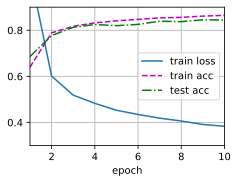

In [9]:
# 9.设置超参数并执行训练(lr在4.定义优化器中直接定义好了)
num_epochs = 10
train_ch3(net,train_iter,test_iter,loss,num_epochs,trainer)

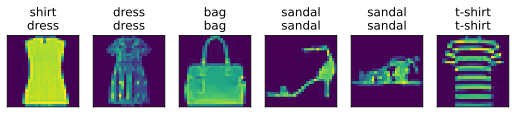

In [10]:
# 10.预测与可视化展示
def get_fashion_mnist_labels(labels):  #@save
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #@save
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 图片张量
            ax.imshow(img.numpy())
        else:
            # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def predict_ch3(net, test_iter, n=6):  #@save
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)